# Experiment: does the treatment move activation?

Business question: what is the estimated treatment effect, and did allocation and guardrails support a credible read?

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
ARTIFACTS = ROOT / "artifacts"
with (ARTIFACTS / "results.json").open() as handle:
    results = json.load(handle)

def table(name, n=8):
    frame = pd.read_csv(ARTIFACTS / "tables" / name)
    display(frame.head(n))
    return frame

def figure(name):
    png = ARTIFACTS / "figures" / f"{name}.png"
    svg = ARTIFACTS / "figures" / f"{name}.svg"
    assert png.exists() and svg.exists(), f"missing paired figure outputs for {name}"
    assert "<svg" in svg.read_text(encoding="utf-8")[:1000]
    display(Image(filename=str(png), width=640))
    return png, svg


,arm,customers,activations,activation_rate,d30_rate,sustained_engagement_d30_rate
0,control,18647,12985,0.696359,0.395774,0.344506
1,treatment,18693,14730,0.787996,0.427058,0.390467


,guardrail,value,threshold,p_value,status,definition
0,sample_ratio_mismatch,0.500616,0.02,0.811841,pass,"Prespecified expected 50:50 allocation, two-si..."
1,max_absolute_smd,0.022554,0.10,NaN,pass,NaN
2,minimum_detectable_effect,0.013342,0.00,NaN,context,"Normal-approximation MDE, not a pass/fail safe..."
3,support_contact_rate_difference,0.018741,0.05,NaN,pass,Treatment minus control mean support contacts ...
4,failed_payment_rate_difference,-0.005422,0.03,NaN,pass,Treatment minus control first-week failed-atte...
5,incentive_cost_per_customer,0.350000,0.50,NaN,pass,Mean fictional incentive currency units per tr...


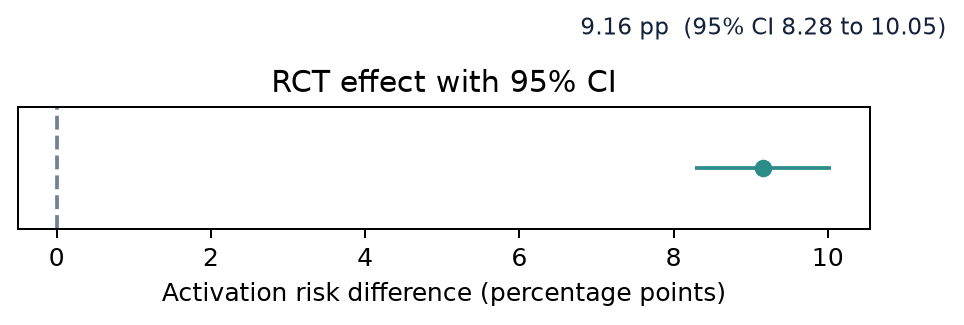

{'primary_metric': 'first_week_activation', 'control_rate': 0.6963586635919987, 'treatment_rate': 0.7879955063392714, 'risk_difference': 0.09163684274727268, 'ci_low': 0.08281129558889232, 'ci_high': 0.10046238990565305, 'z_statistic': 20.241535395248512, 'p_value': 0.0, 'mde': 0.013341703611964023, 'eligible_per_arm': 18647.0, 'claim_scope': 'Randomized experiment estimate for eligible customers.'}


In [2]:
summary = table('experiment_summary.csv')
guardrails = table('rct_guardrails.csv', n=12)
figure('rct_effect_ci')
print(results['experiment'])

In [3]:
print('Evidence: the estimate and interval come from results.json; assignment quality and operational checks come from rct_guardrails.csv.')
print('Decision: ship only if the primary metric and guardrails meet the pre-specified decision rule; otherwise iterate or rerun.')

Evidence: the estimate and interval come from results.json; assignment quality and operational checks come from rct_guardrails.csv.
Decision: ship only if the primary metric and guardrails meet the pre-specified decision rule; otherwise iterate or rerun.


**Uncertainty and scope.** Uncertainty: confidence intervals quantify sampling uncertainty under the experiment model; synthetic data and the stated guardrails limit external validity.

**Decision framing.** Treat the generated artifacts as an auditable working read: inspect the source table, check assumptions, and validate the proposed action with an appropriate follow-up measurement.